<a href="https://colab.research.google.com/github/adtapiagonzalez/PracticasRedesNeuronales_Adrian_Tapia/blob/main/PRACTICA_03_Adrian_Tapia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color="darkorange" size="10"><b>03. Regresión con MLP</b></font>

# Adrián Manuel Tapia González
# adtapia@ucm.es

# Ejercicio 1
Con los datos de este ejemplo crea una red neuronal que sea capaz de generar un error de cero (es decir, la linea de MLP atraviesa todos los puntos).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import torch

In [ ]:
# Adjunto los datos del ejercicio
X = np.array(
    [258.0, 270.0, 294.0, 320.0, 342.0, 368.0, 396.0, 446.0, 480.0, 586.0]
)[:, np.newaxis]

Y = np.array(
    [236.4, 234.4, 252.8, 298.6, 314.2, 342.2, 360.8, 368.0, 391.2, 390.8]
)

print(X)
print(Y)

[[258.]
 [270.]
 [294.]
 [320.]
 [342.]
 [368.]
 [396.]
 [446.]
 [480.]
 [586.]]
[236.4 234.4 252.8 298.6 314.2 342.2 360.8 368.  391.2 390.8]


In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression() # Se hace la regresión lineal de X sobre Y
lr.fit(X, Y)

X_range = np.arange(250, 600, 10)[:, np.newaxis]
y_linear = lr.predict(X_range)

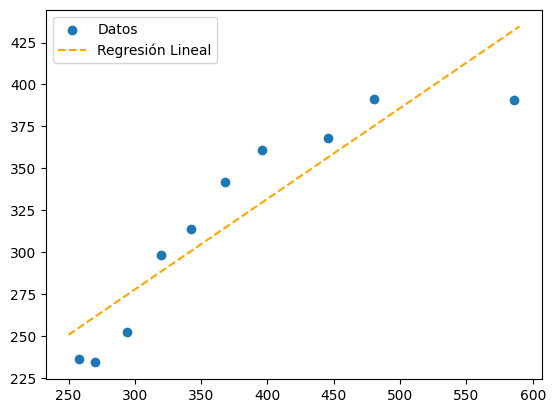

In [ ]:
plt.scatter(X, Y, label="Datos")
plt.plot(X_range, y_linear, label="Regresión Lineal", linestyle="--", color="orange")
plt.legend()
plt.show()

A continuación, se preparan los datos.

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# Se normaliza X e Y
x_mean, x_std = X.mean(), X.std()
y_mean, y_std = Y.mean(), Y.std()

X_norm = (X - x_mean) / x_std
Y_norm = (Y - y_mean) / y_std

# Se pasa a tensores
tensor_X = torch.Tensor(X_norm)
tensor_Y = torch.Tensor(Y_norm)

# Se crea el dataset y el dataloader
my_dataset = TensorDataset(tensor_X,tensor_Y)
my_dataloader = DataLoader(my_dataset)

Ahora se define la misma red

In [ ]:
class MLP(torch.nn.Module):
    def __init__(self, X_nvars, num_neuronas): # Se añade como argumento num_neuronas,
                                               # que definirá el número de neuronas
                                               # indicadas en las capas de la red
        super().__init__()

        self.layers = torch.nn.Sequential(

            # Capa oculta 1
            torch.nn.Linear(X_nvars, num_neuronas),
            torch.nn.ReLU(), # Se mantiene la función de activación ReLU

            # Capa oculta 2
            torch.nn.Linear(num_neuronas, num_neuronas),

            torch.nn.ReLU(),


            # output layer
            torch.nn.Linear(num_neuronas, 1), # El argumento num_neuronas coincide
                                              # con las neuronas de entrada y las de salida
        )

    def forward(self, x):
        output = self.layers(x)
        return output

# Se crea la red y se definen los hiper-parámetros
# Se fija la semilla
torch.manual_seed(1)

# Se fijan los hiper-parámetros
# Se crea el modelo
model = MLP(X_nvars=1, num_neuronas = 50) # Se decide una arquitectura de 50 neuronas por capa

# Se define la función loss, siendo MSE al tratarse de un problema de regresión lineal
loss_fn = torch.nn.MSELoss()

# Se elige el optimizador
optimizer = torch.optim.SGD(model.parameters(), lr=0.01) # Se baja el learning rate

import torch.nn.functional as F

num_epochs = 5000 # Se aumenta el número de épocas

loss_history = []

for epoch in range(num_epochs):
    model = model.train()

    for batch_idx, (features, targets) in enumerate(my_dataloader):

        output = model(features)
        loss = loss_fn(output, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        if not batch_idx % 100:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                # f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss.item():.2f}"
            )

    loss_history.append(loss.item())

# Se evalúa el funcionamiento del modelo
model.eval()

# Se predicen los valores del rango X_range segun el MLP
# Se pasan a un tensor normalizado
X_range_norm = (X_range - x_mean) / x_std
X_range_norm = torch.tensor(X_range_norm, dtype=torch.float32)

# Se meten en el modelo
y_mlp_norm = model(X_range_norm)

# Ahora se desnormalizan para que estén en la misma escala
y_mlp_norm = y_mlp_norm.detach().numpy().astype(np.float64)
y_mlp = y_mlp_norm * y_std + y_mean

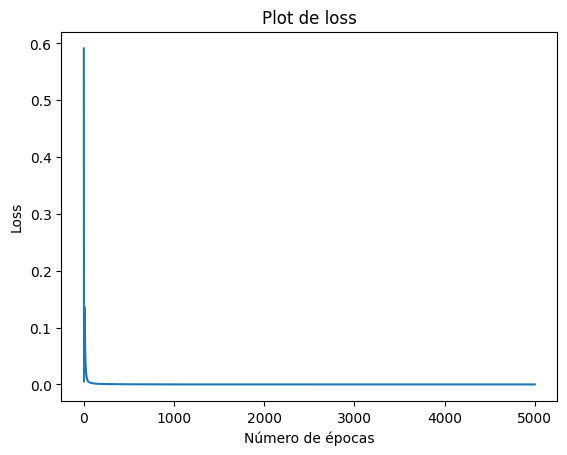

In [ ]:
# Plot de loss
plt.plot(loss_history)
plt.title("Plot de loss")
plt.xlabel("Número de épocas")
plt.ylabel("Loss")
print("\n")

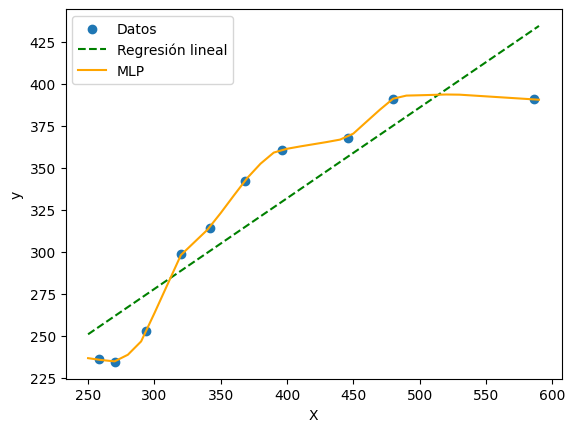

In [ ]:
# Plot con los resultados
# Los datos originales
plt.scatter(X, Y, label="Datos")

# Los datos predichos por la regresion lineal
plt.plot(X_range, y_linear, label="Regresión lineal", linestyle="--", color='green')

# Los datos predichos por el MLP
plt.plot(X_range, y_mlp, label="MLP", color='orange')

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

Como se observa en la gráfica, se ha conseguido un loss de prácticamente 0, logrando que la recta pase por todos los puntos.

# Ejercicio 2
Usando el código siguiente, construye un MLP que se ajuste razonablemente a los puntos de ese seno. Puedes jugar con la creación de datos.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import torch

(100,)
(100,)


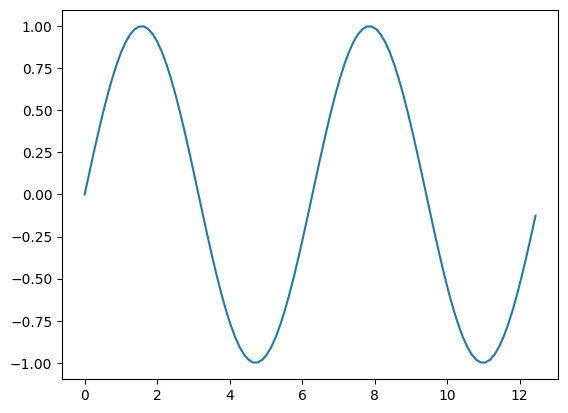

In [ ]:
# Creamos los datos, en este caso un seno

import numpy as np

cycles = 2  # numero de periodos
n = 100     # numero de datos en x

length = 2 * np.pi * cycles

x = np.arange(0, length, length / n)
y = np.sin(x)

plt.plot(x, y, '-')

print(x.shape)
print(y.shape)

In [ ]:
# Se preparan los datos

from torch.utils.data import TensorDataset, DataLoader

# Normalización de x e y
x_mean, x_std = x.mean(), x.std()
y_mean, y_std = y.mean(), y.std()

x_norm = (x - x_mean) / x_std
y_norm = (y - y_mean) / y_std

# Se pasan a tensores
tensor_x = torch.Tensor(x_norm)
tensor_y = torch.Tensor(y_norm)

# Se crea el dataset y dataloader
my_dataset = TensorDataset(tensor_x,tensor_y)
my_dataloader = DataLoader(my_dataset)

In [ ]:
class MLP(torch.nn.Module):
    def __init__(self, X_nvars, num_neuronas):
        super().__init__()

        self.layers = torch.nn.Sequential(

            # Capa oculta 1
            torch.nn.Linear(X_nvars, num_neuronas),
            torch.nn.Tanh(),  # En este caso, se emplea la función de activación Tanh.
                              # Se considera más adecuada por la naturaleza de los datos,
                              # que se encuentran en valores entre -1 y 1.

            # Capa oculta 2
            torch.nn.Linear(num_neuronas, num_neuronas),

            torch.nn.Tanh(),


            # output layer
            torch.nn.Linear(num_neuronas, 1),
        )

    def forward(self, x):
        output = self.layers(x)
        return output


# Se crea la red y se definen los hiper-parámetros
torch.manual_seed(1)

# Se crea el modelo MLP
model = MLP(X_nvars=1, num_neuronas = 25) # 25 neuronas por cada capa


loss_fn = torch.nn.MSELoss()


optimizer = torch.optim.SGD(model.parameters(), lr=0.01) # Se establece un learning rate de 0.01

import torch.nn.functional as F


num_epochs = 1000 # Se aumenta el número de épocas


loss_history = []

for epoch in range(num_epochs):
    model = model.train()

    for batch_idx, (features, targets) in enumerate(my_dataloader):

        output = model(features)
        loss = loss_fn(output, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        if not batch_idx % 100:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                # f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss.item():.2f}"
            )

    loss_history.append(loss.item())

# Se evalúa el funcionamiento del modelo

model.eval()

# Se crean nuevos datos para evaluar el modelo
x_range = np.linspace(0, length, 1000) # Se da un rango distinto

# Se pasan a un tensor normalizado
x_range_norm = (x_range - x_mean) / x_std
x_range_norm = torch.tensor(x_range_norm, dtype=torch.float32).unsqueeze(1)
# Se pone unsqueeze(1) para convertir el tensor de x de (100) a (100, 1),
# que es lo que la red espera como entrada

# Se meten en el modelo
y_mlp_norm = model(x_range_norm)

# Ahora se desnormalizan para que estén en la misma escala
y_mlp_norm = y_mlp_norm.detach().numpy().astype(np.float64)
y_mlp = y_mlp_norm * y_std + y_mean

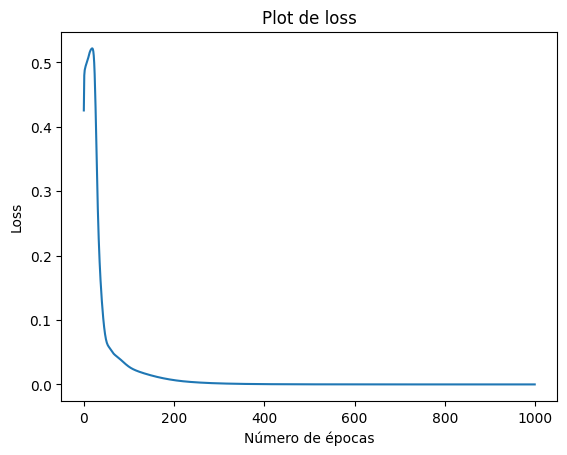

In [ ]:
plt.plot(loss_history)
plt.title("Plot de loss")
plt.xlabel("Número de épocas")
plt.ylabel("Loss")
print("\n")

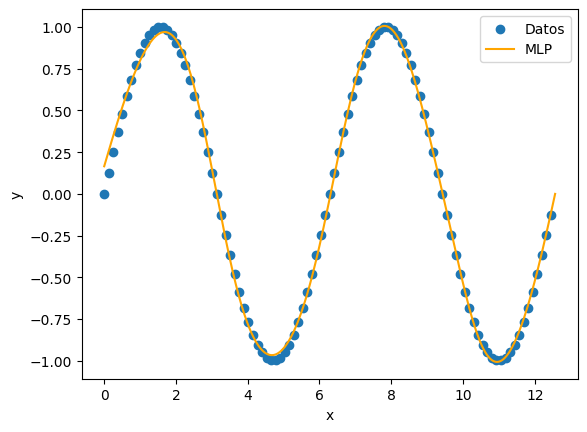

In [ ]:
# Plot con los resultados
# Los datos originales
plt.scatter(x, y, label="Datos")

# Los datos predichos por el MLP
plt.plot(x_range, y_mlp, label="MLP", color='orange')

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Con un loss cercano a 0.05, se conisgue aproximadamente que el MLP logre pasar por todos los puntos de la función.

# Ejercicio 3
Regresión con datos de felicidad

Se analizan unos datos obtenido de Kaggle.com sobre la encuesta de felicidad de 2021: [enlace](https://https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2021)

Una vez limpiados y preparados la base de datos consta de 9 variables predictoras y una variable criterio:

**Criterio**: Life.Ladder.

**Predictoras**: year, Log.GDP.per.capita, Social.support, Healthy.life.expectancy.at.birth, Freedom.to.make.life.choices, Generosity, Perceptions.of.corruption, Positive.affect, Negative.affect.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import torch

In [ ]:
# Funciones para importar y preparar los datos

import pandas as pd
url = 'https://raw.githubusercontent.com/mcstllns/UNIR2024/main/data-happiness.csv'
data  = pd.read_csv(url)
print(data.keys())
data.head()

# El fichero tiene datos perdidos y hay que eliminar las filas
data = data.dropna()

# Creamos conjuntos X e y
X = data.drop('Life.Ladder', axis=1)
y = data['Life.Ladder']

print(X.head())
print(y.head())

Index(['year', 'Life.Ladder', 'Log.GDP.per.capita', 'Social.support',
       'Healthy.life.expectancy.at.birth', 'Freedom.to.make.life.choices',
       'Generosity', 'Perceptions.of.corruption', 'Positive.affect',
       'Negative.affect'],
      dtype='object')
   year  Log.GDP.per.capita  Social.support  Healthy.life.expectancy.at.birth  \
0  2008               7.370           0.451                             50.80   
1  2009               7.540           0.552                             51.20   
2  2010               7.647           0.539                             51.60   
3  2011               7.620           0.521                             51.92   
4  2012               7.705           0.521                             52.24   

   Freedom.to.make.life.choices  Generosity  Perceptions.of.corruption  \
0                         0.718       0.168                      0.882   
1                         0.679       0.190                      0.850   
2                         0.

In [ ]:
# preparamos los datos
from torch.utils.data import TensorDataset, DataLoader

# Se normalizan los datos
x_mean, x_std = X.mean(), X.std()
y_mean, y_std = y.mean(), y.std()

X_norm = (X - x_mean) / x_std
y_norm = (y - y_mean) / y_std

# Se pasa a tensores
tensor_X = torch.from_numpy(X_norm.values).float()
tensor_y = torch.from_numpy(y_norm.values).float().view(-1, 1)
# Se asegura que sea float32 para que no dé error, pues el modelo espera float32
# como tipos de datos. Además, se añade .view(-1, 1) ya que el modelo espera recibir
# un tensor con forma (1708, 1). Sin añadirlo, el tensor tendría forma (1708).

# Se crea el dataset y el dataloader
my_dataset = TensorDataset(tensor_X,tensor_y) # create your datset
my_dataloader = DataLoader(my_dataset, batch_size = 32) # create your dataloader

In [ ]:
print(tensor_X.shape)
print(tensor_y.shape)

torch.Size([1708, 9])
torch.Size([1708, 1])


In [ ]:
class MLP(torch.nn.Module):
    def __init__(self, X_nvars, num_neuronas):
        super().__init__()

        self.layers = torch.nn.Sequential(

            # Capa oculta 1
            torch.nn.Linear(X_nvars, num_neuronas),
            torch.nn.ReLU(),

            # Capa oculta 2
            torch.nn.Linear(num_neuronas, num_neuronas),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(num_neuronas, 1),
        )

    def forward(self, x):
        output = self.layers(x)
        return output

# Se crea la red y se definen los hiper-parámetros
torch.manual_seed(1)

# Se crea el modelo MLP
model = MLP(X_nvars=9, num_neuronas = 100) # Se ponen 100 neuronas en cada capa

# Se define la función loss (MSE)
loss_fn = torch.nn.MSELoss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

import torch.nn.functional as F


num_epochs = 500 # Se aumenta el número de épocas

loss_history = []

for epoch in range(num_epochs):
    model = model.train()

    for batch_idx, (features, targets) in enumerate(my_dataloader):

        output = model(features)
        loss = loss_fn(output, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if not batch_idx % 500 == 0:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                # f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss.item():.2f}"
            )
    loss_history.append(loss.item())


# Se evalúa el funcionamiento del modelo
model.eval()

# Se meten en el modelo
y_mlp_norm = model(tensor_X)

# Ahora se desnormalizan para que estén en la misma escala
y_mlp = y_mlp_norm.detach().numpy().astype(np.float64) * y_std + y_mean # desnormalizan

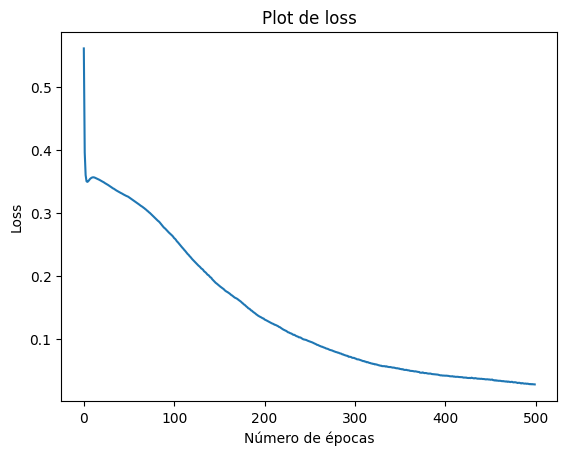

In [ ]:
plt.plot(loss_history)
plt.title("Plot de loss")
plt.xlabel("Número de épocas")
plt.ylabel("Loss")
print("\n")

# Se evalúa el funcionamiento del modelo

model.eval()

# Se meten en el modelo
y_mlp_norm = model(tensor_X)

# Ahora se desnormalizan para que estén en la misma escala
y_mlp = y_mlp_norm.detach().numpy().astype(np.float64) * y_std + y_mean # desnormalizan

Como se puede observar, el MSE llega a ser mucho menor que 0.1. Es decir, muy poco error, por lo que el modelo predice adecuadamente Life.Ladder. Habría que valorar si es deseable o no, pues podría estar indicando un sobreajuste de los datos.